<a href="https://colab.research.google.com/github/hdpark1208/StudyCode/blob/main/Algorithm/BJ/%EC%88%A8%EB%B0%94%EA%BC%AD%EC%A7%883.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 숨바꼭질2

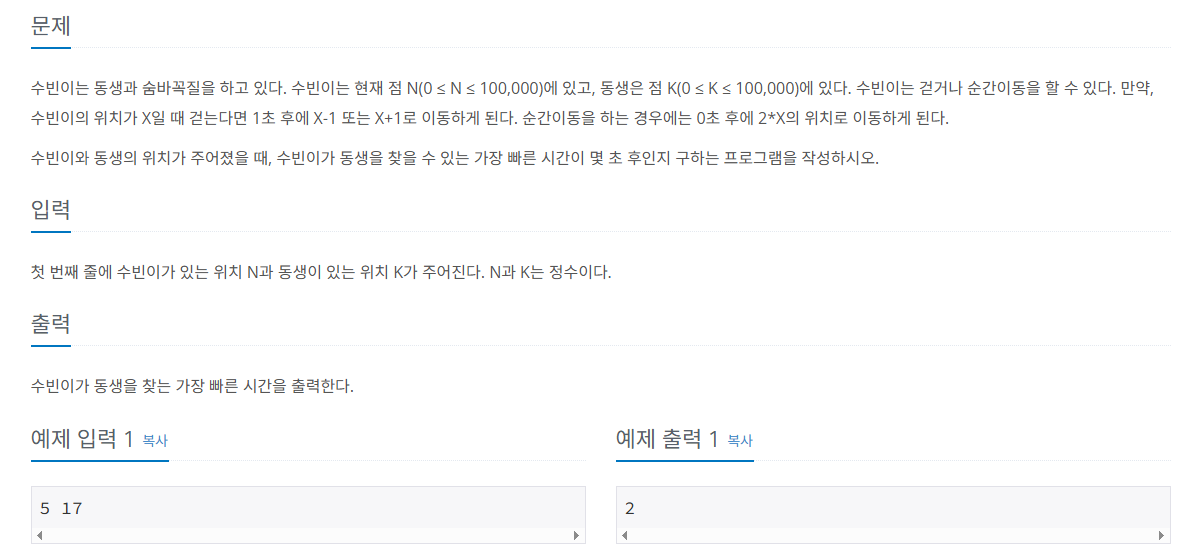

## 입력 출력 및 예제


* 입력

* 출력

* 예제

## 구상

- 순간이동(2*x)의 경우 1초가 아닌 0초로 계산했을 시, 가장 빠른 시간을 구하는 문제
- 가장 빠른 시간의 경로들(숨바꼭질2) 중에서 순간이동이 가장 많이 포함되어 있는 경로가 정답. 임을 보장하는가?
    - 아닌 것 같은데...

- 기존의 방법에서 순간이동일 때 부분만 고쳐주면..?
    - 기존의 bfs가 최단 시간을 보장해주지 않을듯

- 2*x 부분을 다 채우고 시작할까?

## 코드

In [ ]:
# GPT # 0-1 BFS
from collections import deque

N, K = map(int, input().split())
MAX = 100000
INF = 10**9

dist = [INF] * (MAX + 1)
dist[N] = 0

dq = deque([N])

while dq:
    x = dq.popleft()

    for nx, cost in ((2 * x, 0), (x - 1, 1), (x + 1, 1)):
        if 0 <= nx <= MAX:
            nd = dist[x] + cost

            if nd < dist[nx]:
                dist[nx] = nd
                if cost == 0:
                    dq.appendleft(nx)
                else:
                    dq.append(nx)

print(dist[K])

In [4]:
# 숨바꼭질 1 수정

from collections import deque

N, K = map(int, input().split())
MAX = 100000

dist = [-1] * (MAX + 1)
dist[N] = 0

q = deque([N])

while q:
    x = q.popleft()
    if x == K:
        break

    for nx in (x - 1, x + 1, x * 2):
        if 0 <= nx <= MAX and dist[nx] == -1:
            # 수정
            if nx == x*2:
                dist[nx] = dist[x]
            else:
                dist[nx] = dist[x] + 1
            q.append(nx)

print(dist[K])

5 17
2


In [1]:
# 숨바꼭질 2

from collections import deque

N, K = map(int, input().split())
MAX = 100000

dist = [-1] * (MAX + 1)
cnt = [0] * (MAX + 1)

q = deque([N])
dist[N] = 0
cnt[N] = 1

while q:
    x = q.popleft()

    for nx in (x - 1, x + 1, x * 2):
        if 0 <= nx <= MAX:
            # 처음 방문
            if dist[nx] == -1:
                dist[nx] = dist[x] + 1
                cnt[nx] = cnt[x]
                q.append(nx)

            # 이미 방문했지만, 같은 최단 거리로 또 도달
            elif dist[nx] == dist[x] + 1:
                cnt[nx] += cnt[x]

print(dist[K])
print(cnt[K])

KeyboardInterrupt: Interrupted by user

5 2
1 4 4 8 1
9


### 메모



* 0-1 BFS 은 처음 접해본듯
* 다익스트라로도 가능